In [3]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import ydf

In [4]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [5]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [6]:
from ydf import GradientBoostedTreesLearner

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.059405
128 train done
128 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0205543079618544


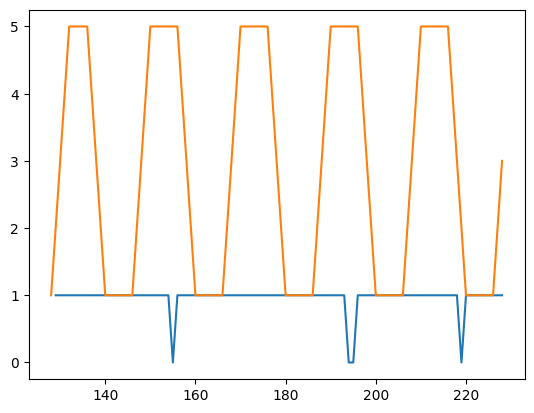

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.189515
256 train done
256 [3.0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5] 101
1.0120286745353375


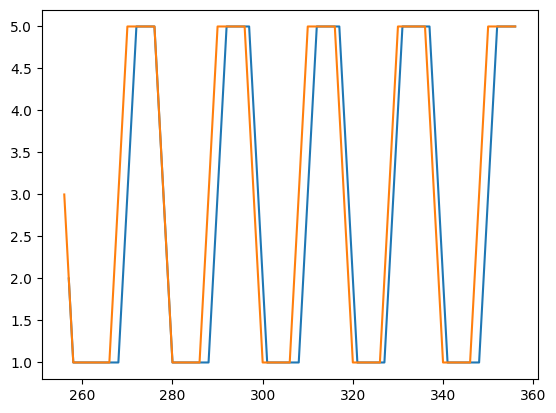

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.141740
512 train done
512 [2.0, 3, 4, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5] 101
0.014020694387527897


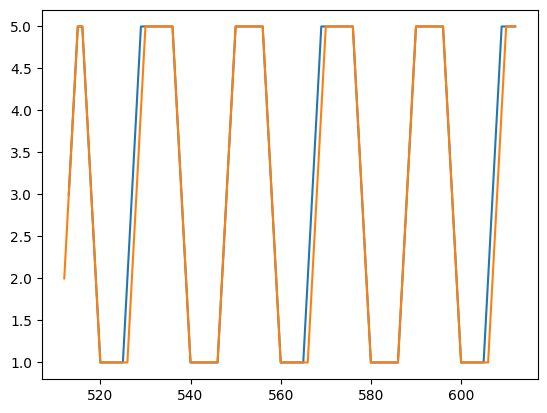

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.226842
750 train done
750 [5.0, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


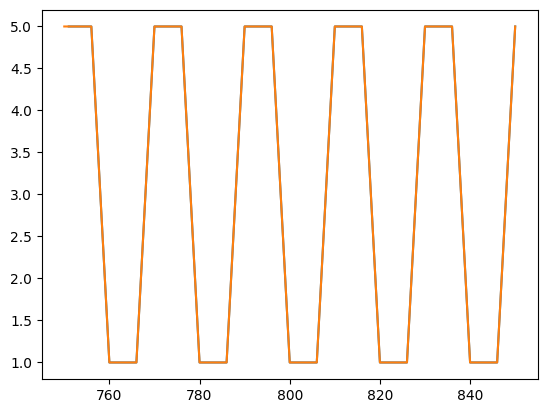

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.313214
1024 train done
1024 [0.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


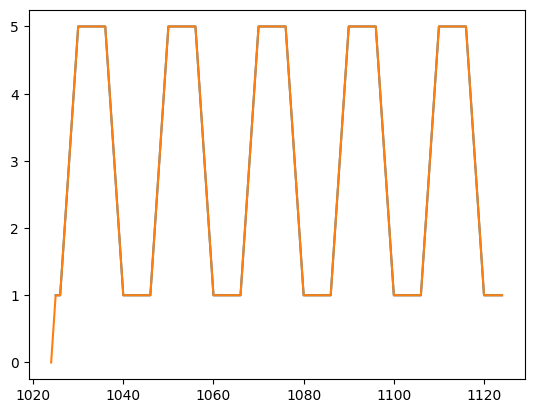

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.616617
1250 train done
1250 [4.0, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


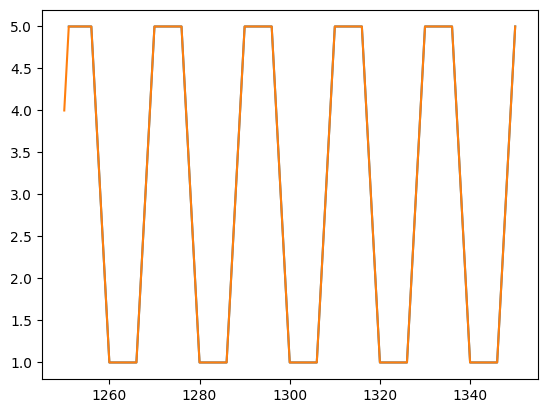

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.434743
1500 train done
1500 [5.0, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


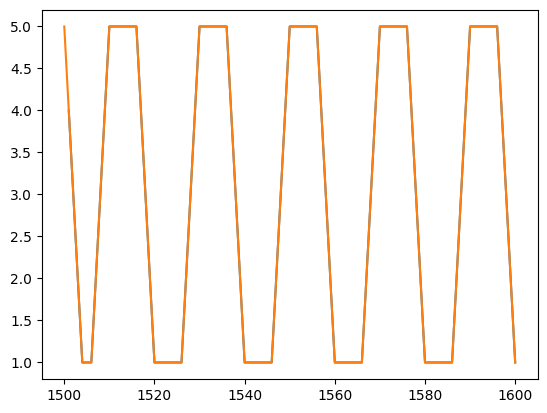

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.949649
2048 train done
2048 [3.0, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


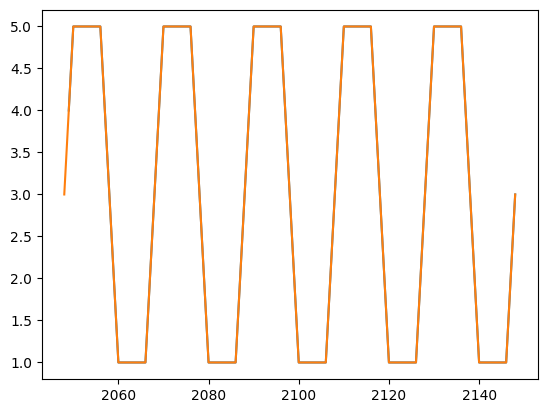

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.047787
128 train done
128 [5.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.1892779714209343


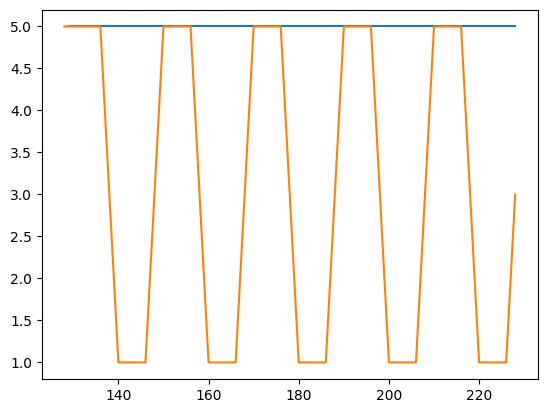

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.104125
256 train done
256 [5.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1] 101
1.1868518338171838


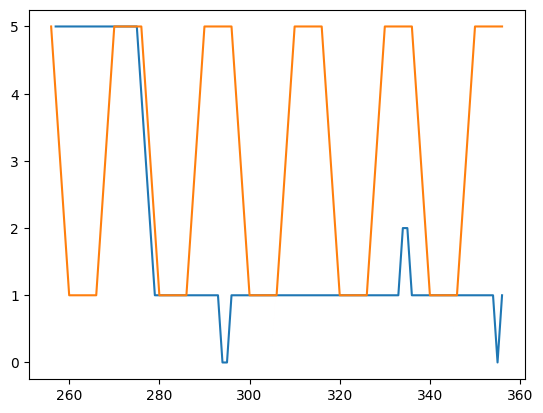

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.247006
512 train done
512 [1.0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.00408239999999978


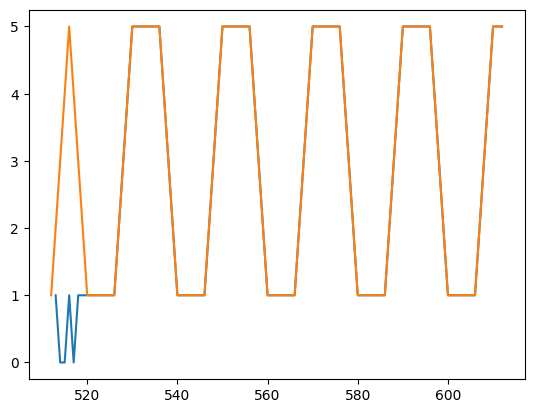

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.311081
750 train done
750 [1.0, 1, 1, 2, 3, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.01863000000000028


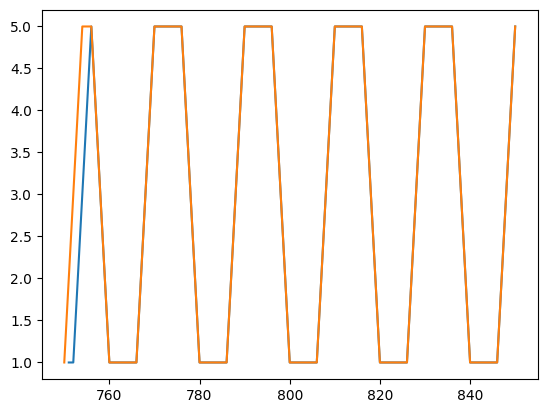

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.569112
1024 train done
1024 [2.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


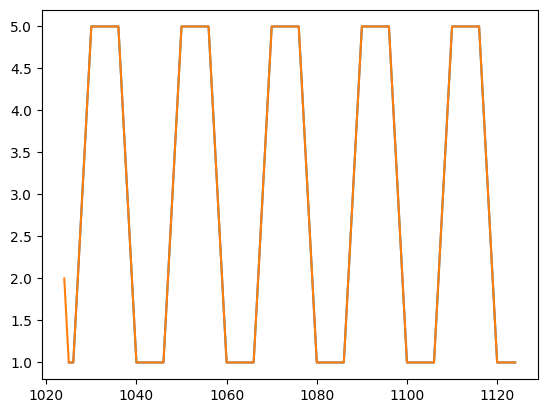

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.436838
1250 train done
1250 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


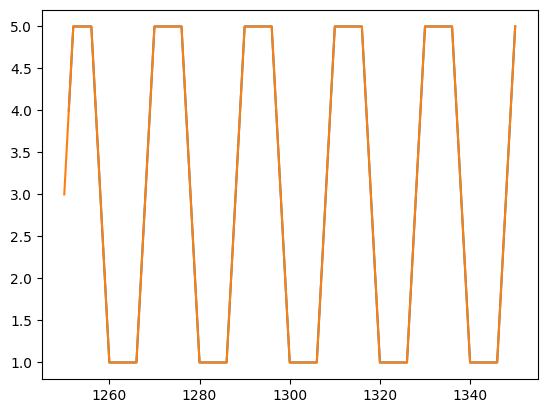

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.546728
1500 train done
1500 [2.0, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


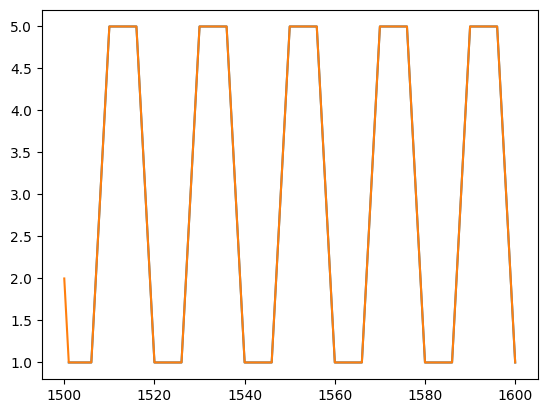

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.740160
2048 train done
2048 [3.0, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


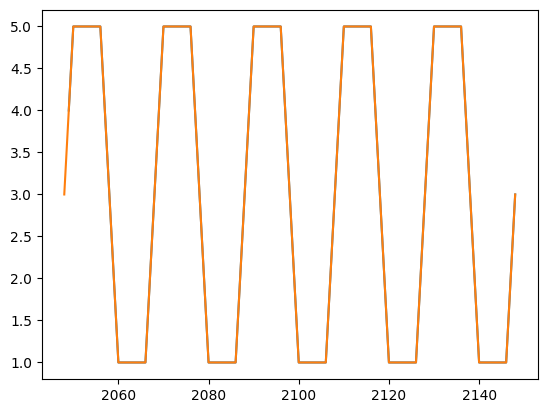

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.060940
128 train done
128 [6.0, 5, 5, 4, 3, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0655543079618541


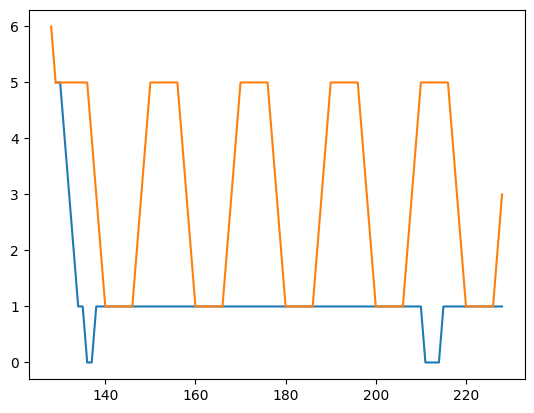

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.075195
256 train done
256 [2.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.4572079882534672


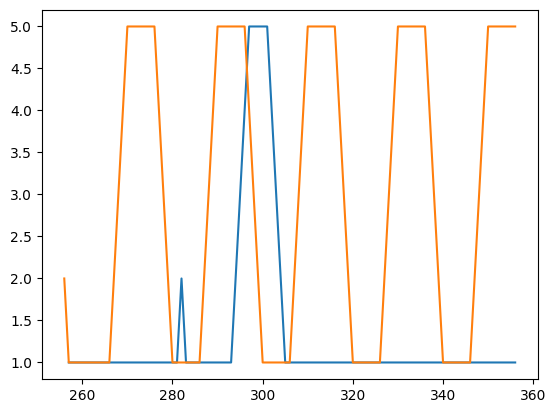

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.246205
512 train done
512 [1.0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.00408239999999978


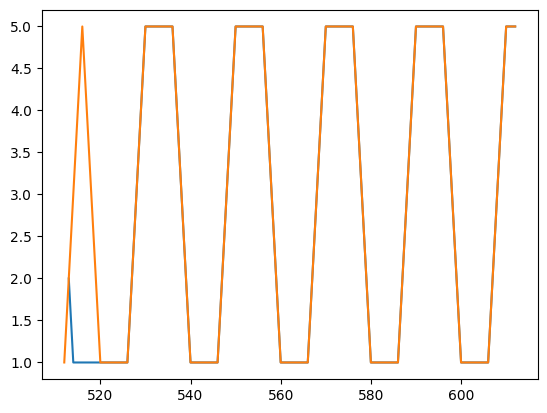

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.310170
750 train done
750 [4.0, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


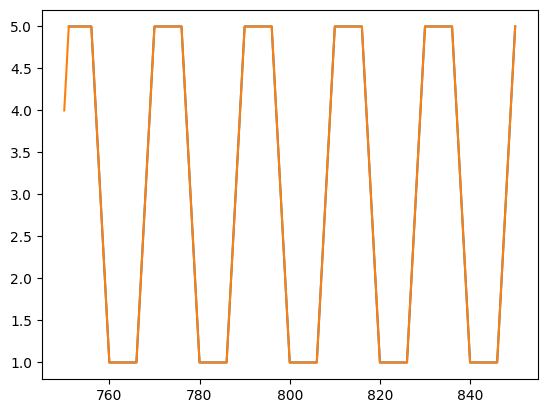

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.334045
1024 train done
1024 [0.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


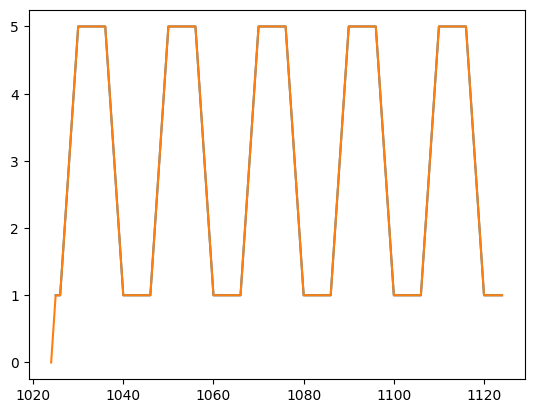

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.301447
1250 train done
1250 [1.0, 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


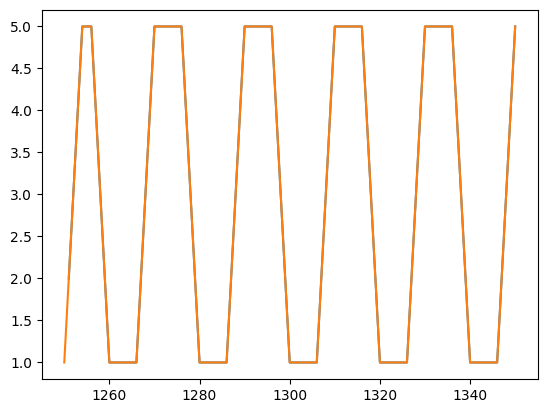

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.457071
1500 train done
1500 [0.0, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


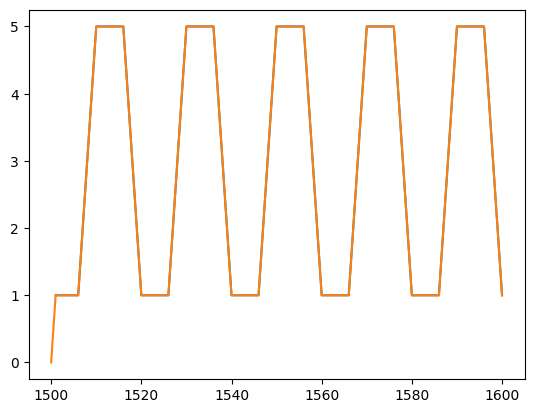

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.548959
2048 train done
2048 [0.0, 1, 2, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


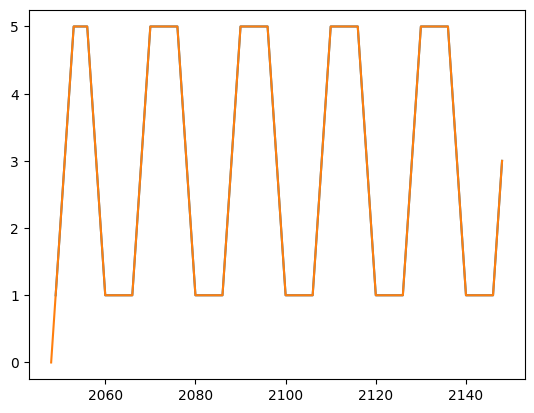

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.285211
128 train done
128 [2.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.2860279714209344


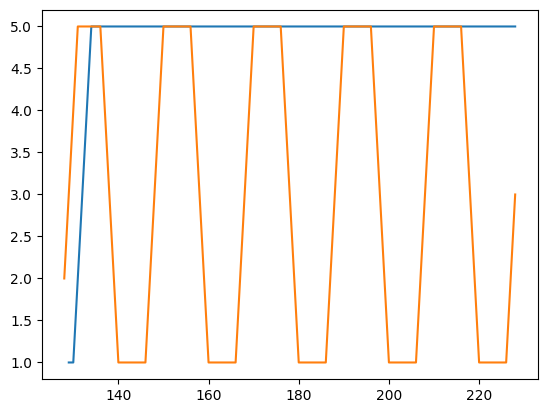

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.163568
256 train done
256 [0.0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5] 101
1.2556738199521407


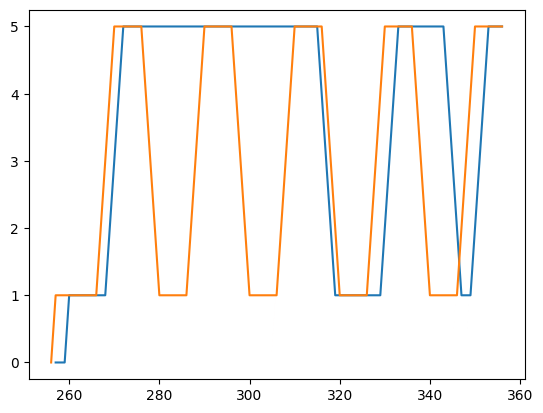

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.253983
512 train done
512 [1.0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.2161956543991954


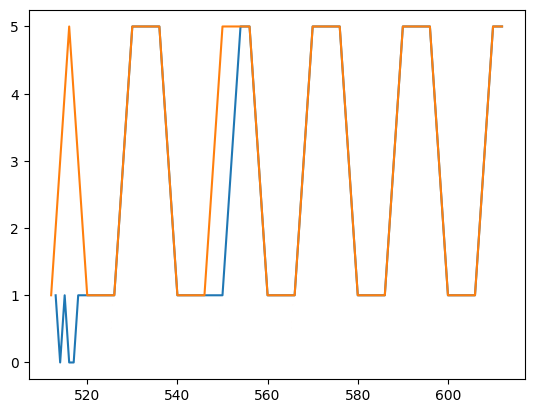

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.250529
750 train done
750 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


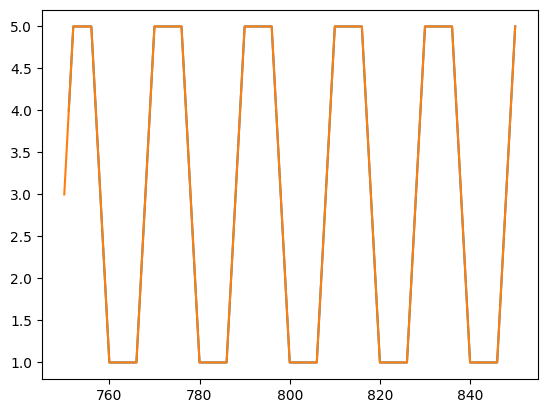

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.532777
1024 train done
1024 [6.0, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


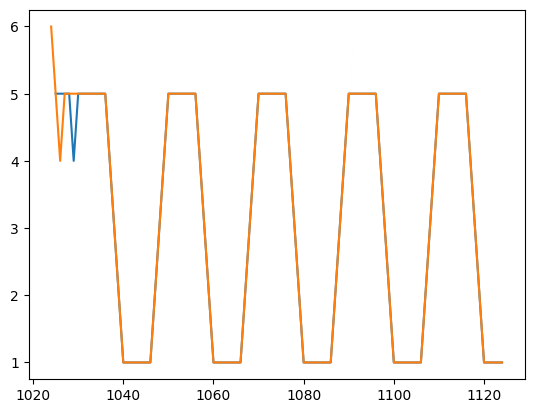

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.455793
1250 train done
1250 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


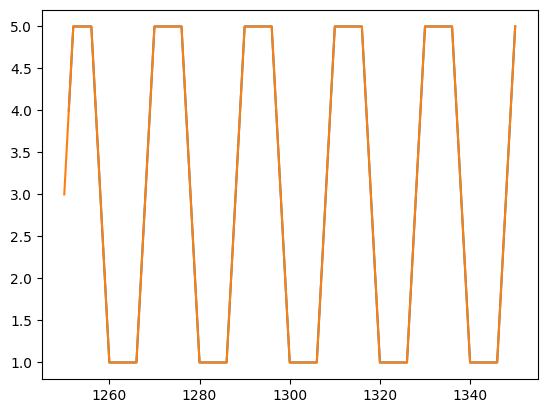

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.458737
1500 train done
1500 [3.0, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


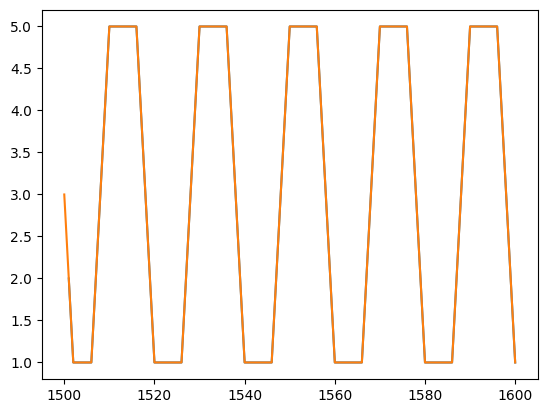

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.582928
2048 train done
2048 [6.0, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


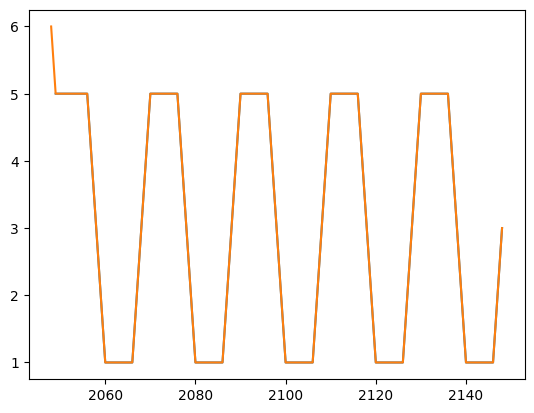

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.076943
128 train done
128 [1.0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.2669288773705918


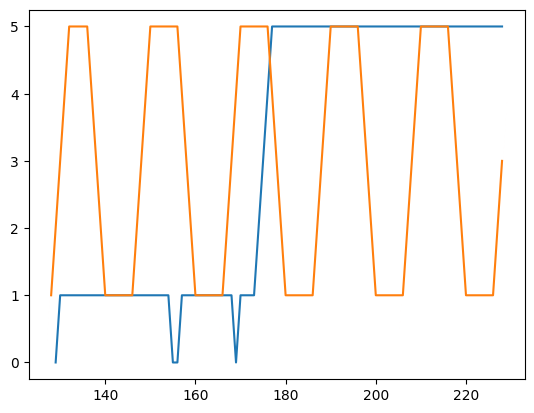

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.131939
256 train done
256 [5.0, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5] 101
0.2915924472137178


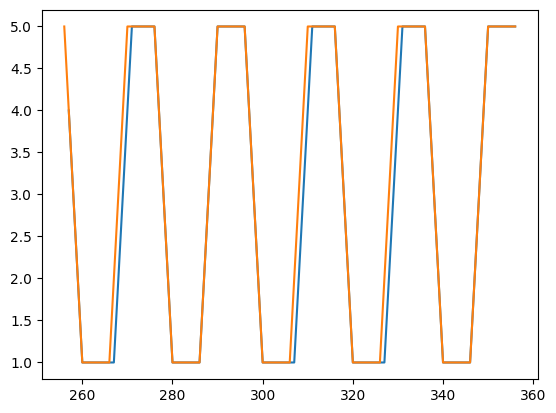

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.344555
512 train done
512 [4.0, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.0


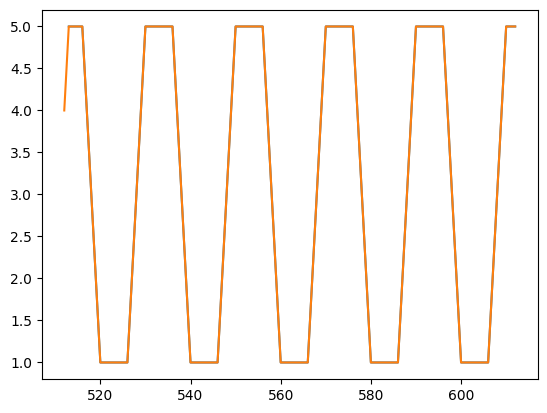

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.256072
750 train done
750 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


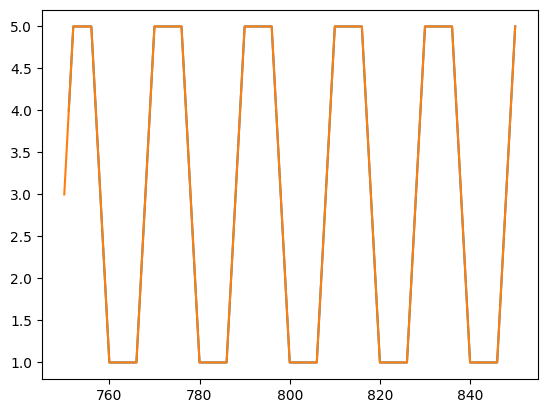

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.558146
1024 train done
1024 [2.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


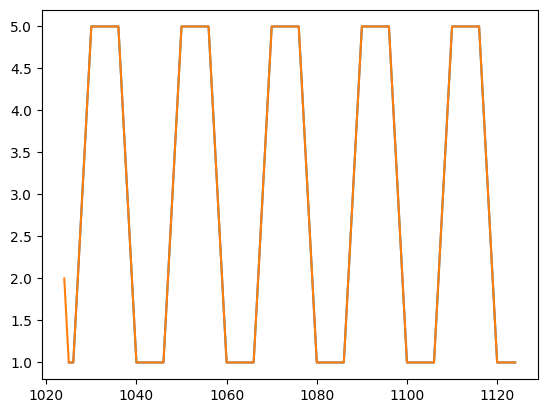

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.370830
1250 train done
1250 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


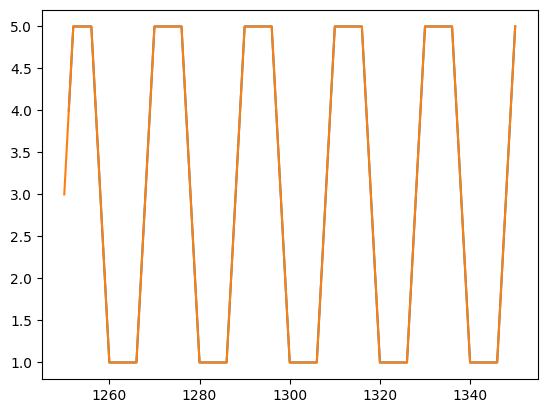

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.315764
1500 train done
1500 [5.0, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


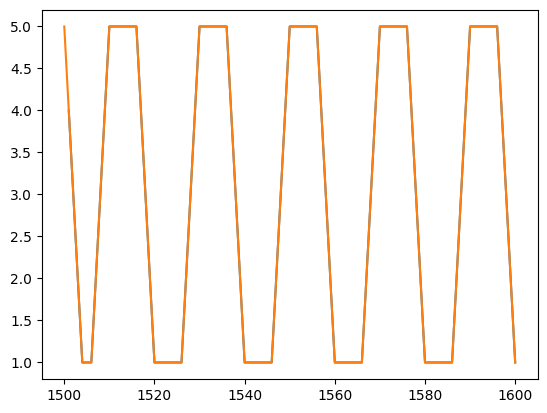

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.357181
2048 train done
2048 [3.0, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


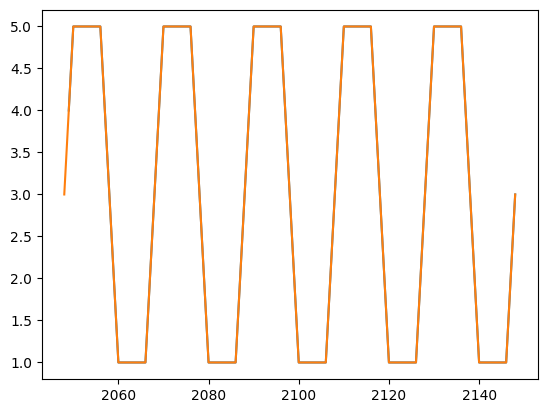

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.075999
128 train done
128 [2.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1] 101
1.0750603814580204


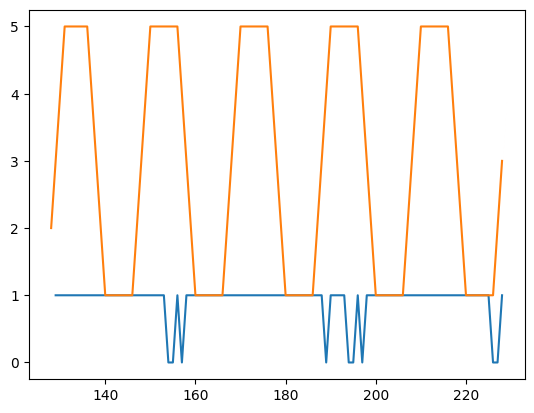

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.135070
256 train done
256 [2.0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1] 101
1.1981529073455748


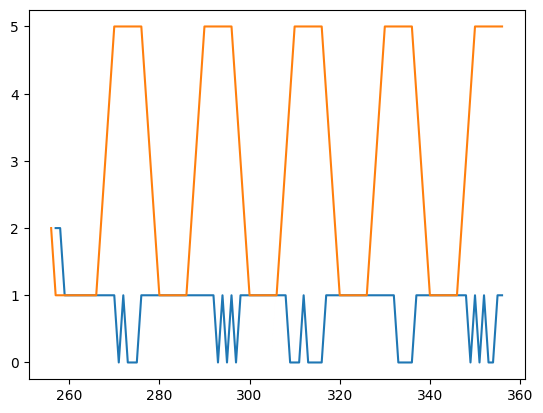

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.194984
512 train done
512 [6.0, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.7996869998459681


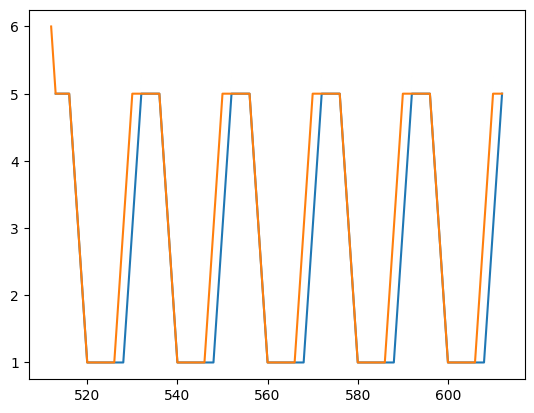

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.242900
750 train done
750 [4.0, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


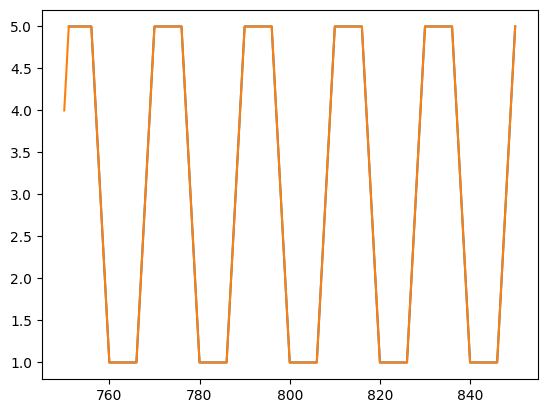

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.344091
1024 train done
1024 [1.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


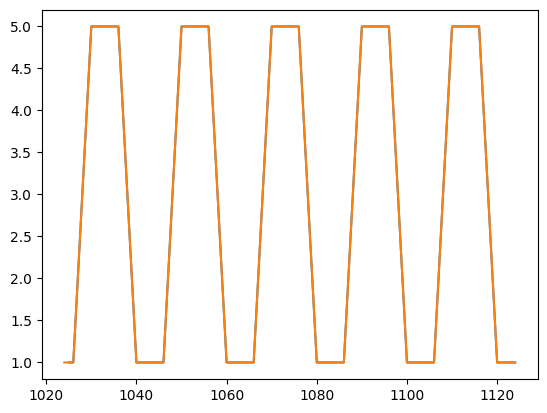

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.411679
1250 train done
1250 [1.0, 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


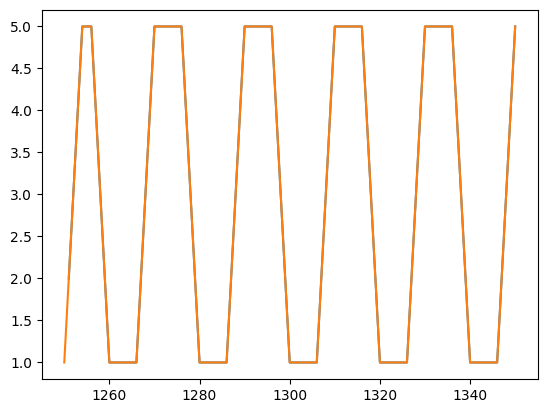

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.338282
1500 train done
1500 [0.0, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


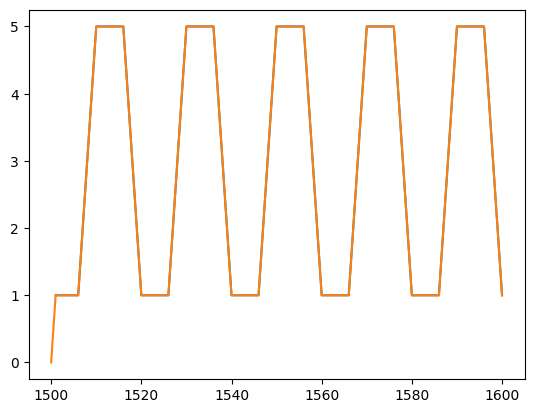

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.321226
2048 train done
2048 [6.0, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


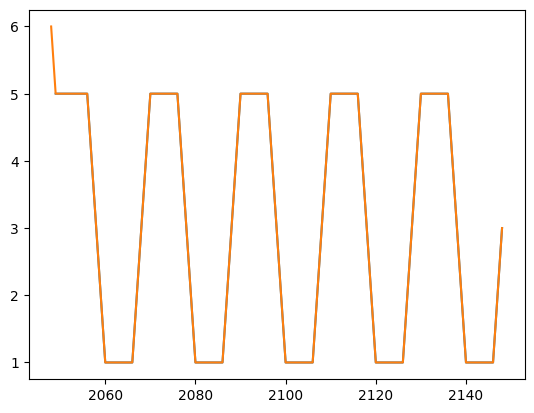

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.072166
128 train done
128 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0205543079618544


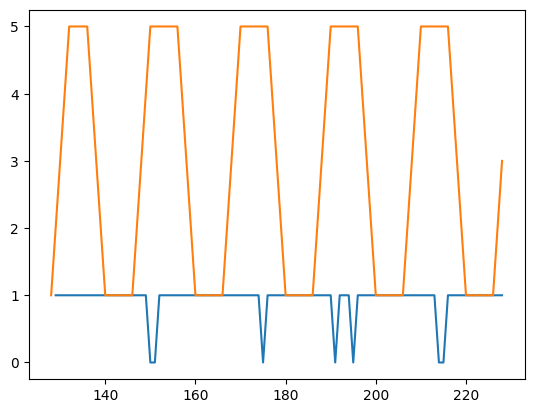

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.072441
256 train done
256 [3.0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5] 101
0.4902242095434397


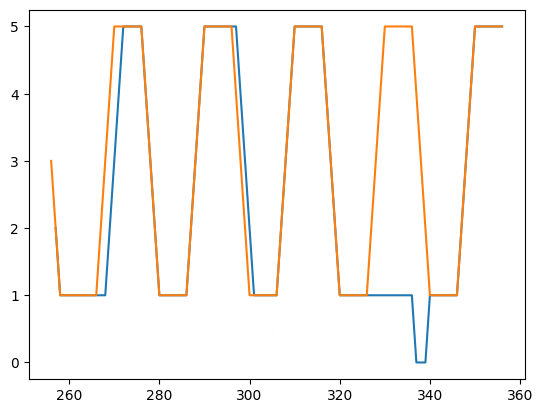

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.128062
512 train done
512 [5.0, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.15552104142285172


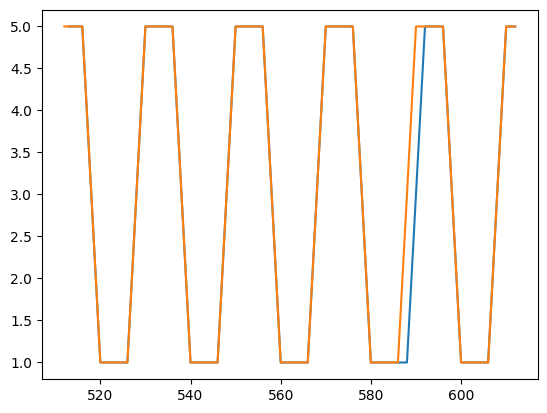

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.247335
750 train done
750 [2.0, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


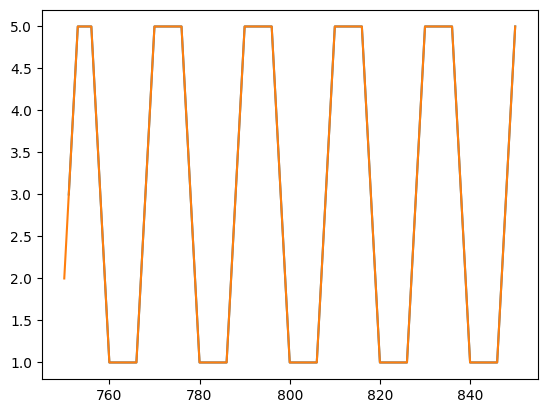

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.283169
1024 train done
1024 [1.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


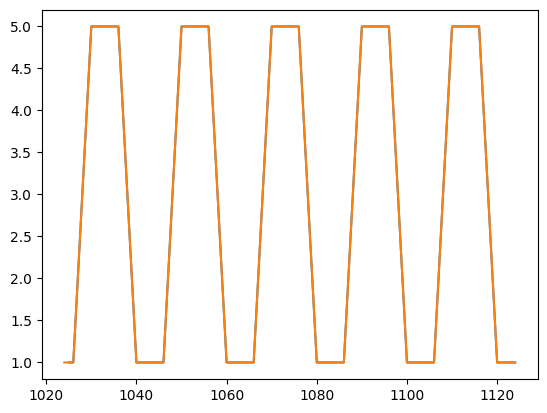

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.374318
1250 train done
1250 [4.0, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


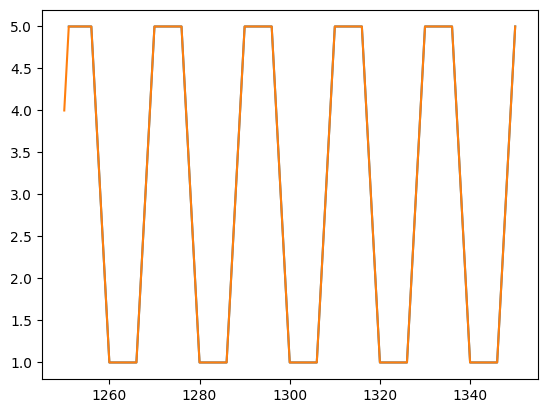

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.403767
1500 train done
1500 [6.0, 5, 4, 3, 2, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


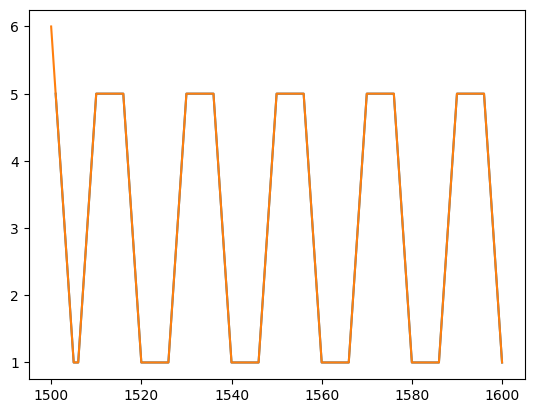

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.733520
2048 train done
2048 [6.0, 6, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


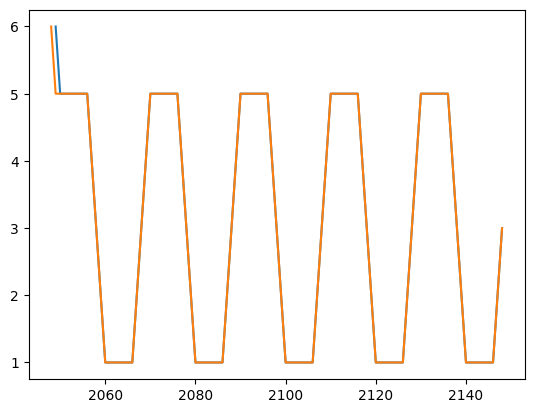

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.088615
128 train done
128 [5.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.1892779714209343


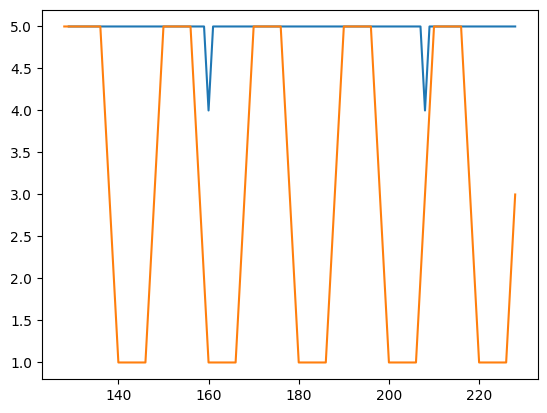

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.082828
256 train done
256 [0.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5] 101
0.0


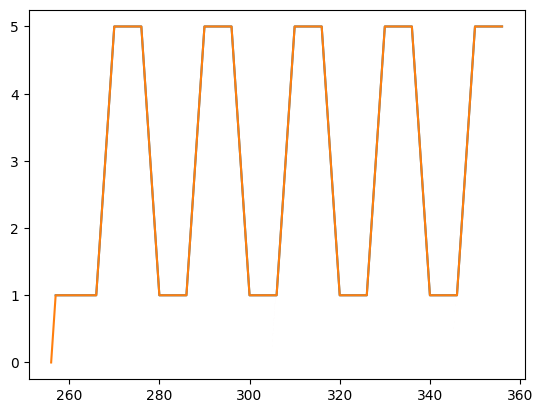

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.256011
512 train done
512 [1.0, 2, 3, 4, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.0972006479194775


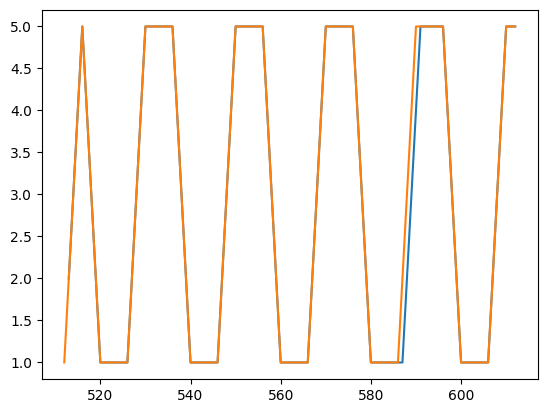

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.368062
750 train done
750 [5.0, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


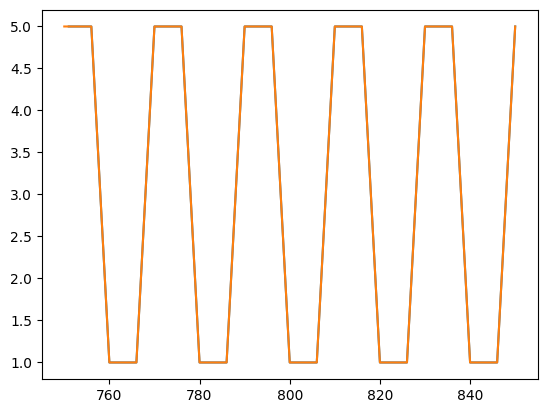

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.238801
1024 train done
1024 [4.0, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


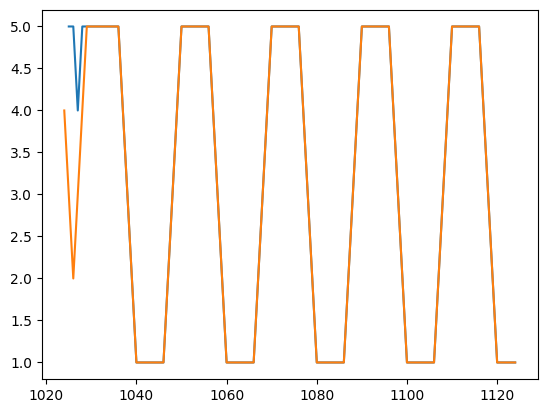

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.726474
1250 train done
1250 [1.0, 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


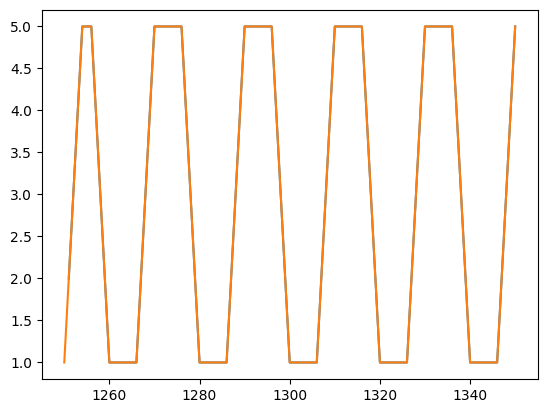

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.483835
1500 train done
1500 [0.0, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


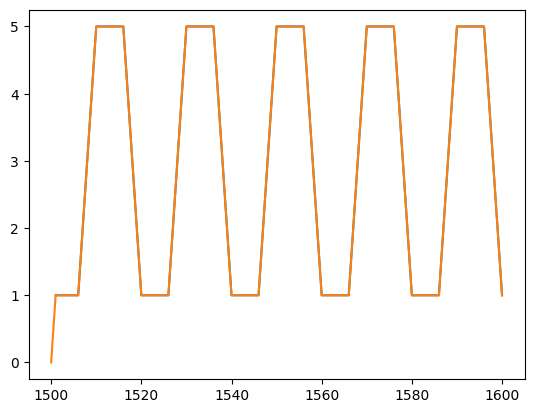

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.772759
2048 train done
2048 [5.0, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


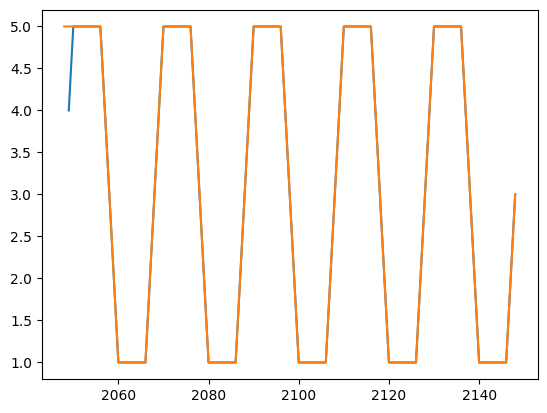

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.127668
128 train done
128 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0205543079618544


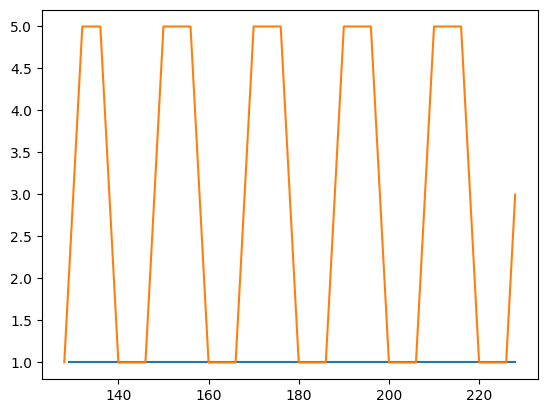

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.220240
256 train done
256 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5] 101
1.130043102552838


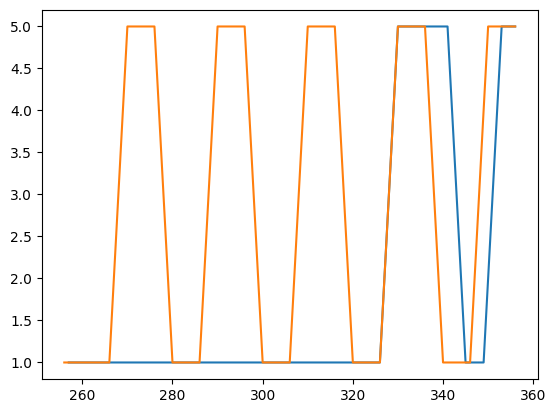

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.293096
512 train done
512 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.10128303942179656


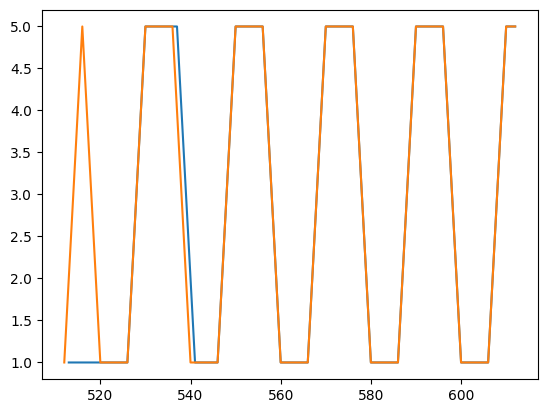

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.433367
750 train done
750 [1.0, 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


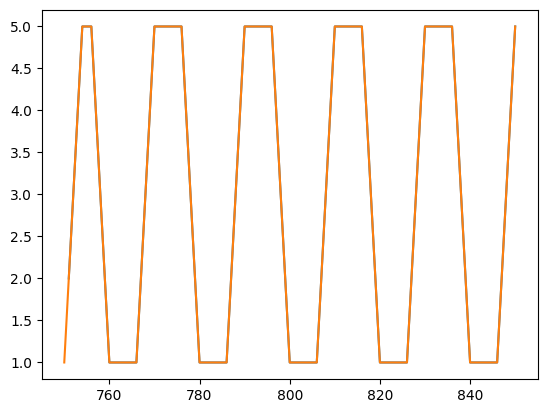

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.406343
1024 train done
1024 [4.0, 5, 4, 3, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


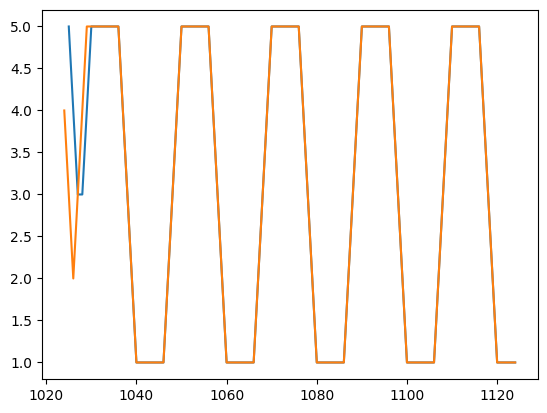

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.749359
1250 train done
1250 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


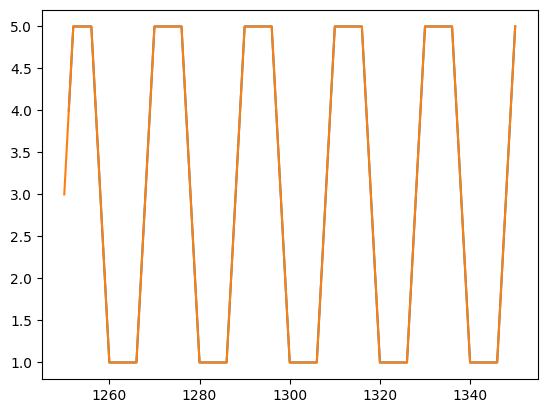

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.633631
1500 train done
1500 [4.0, 3, 2, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


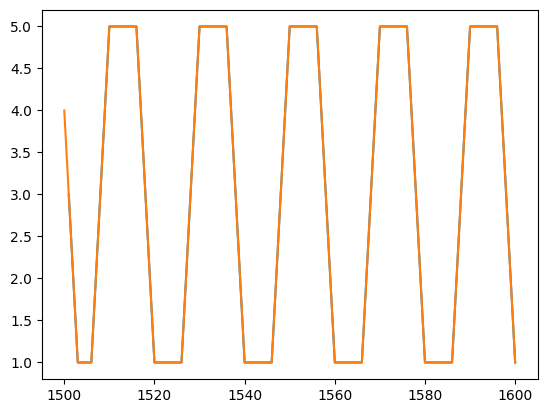

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.575321
2048 train done
2048 [1.0, 2, 3, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


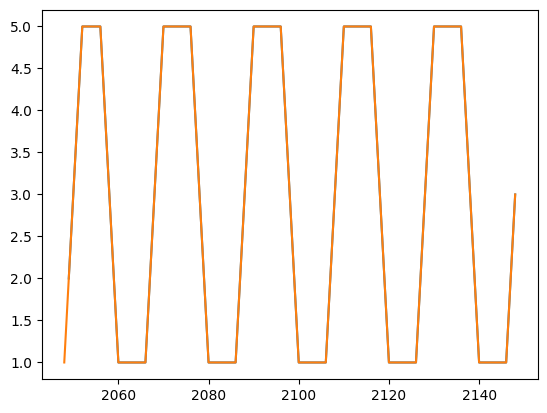

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.099839
128 train done
128 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.3179978635227945


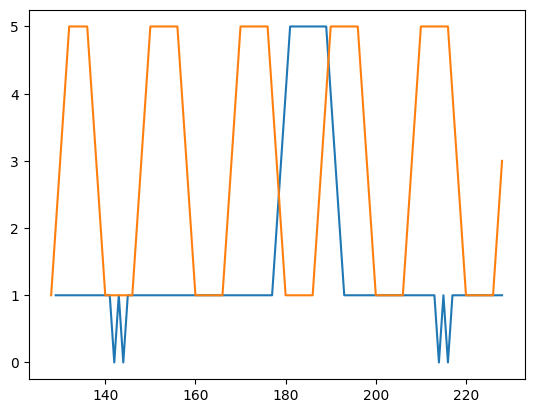

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.129705
256 train done
256 [5.0, 5, 5, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 5, 5, 5, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.540142562380526


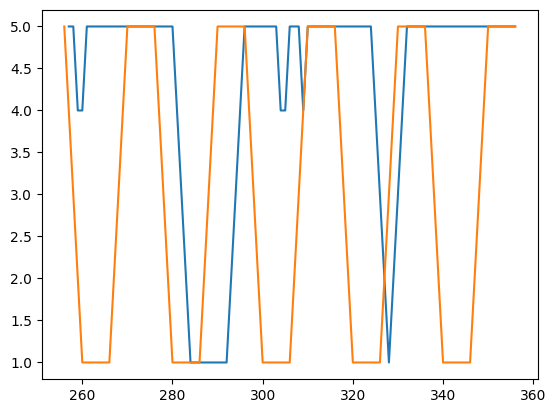

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.129848
512 train done
512 [2.0, 3, 4, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5] 101
0.6986241494170892


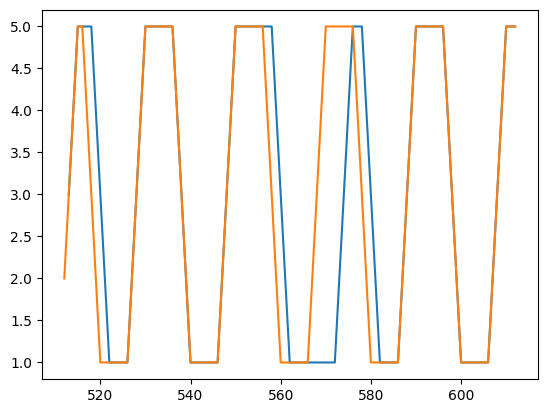

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.279939
750 train done
750 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


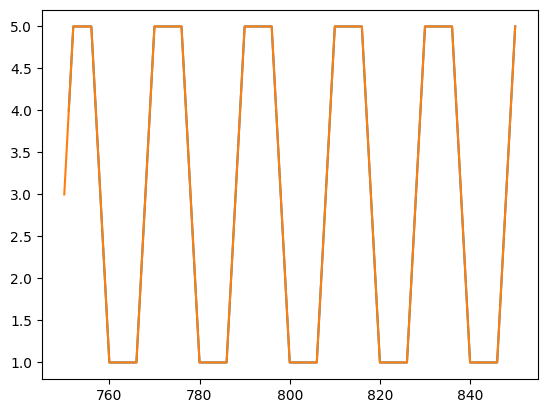

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.187278
1024 train done
1024 [3.0, 2, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


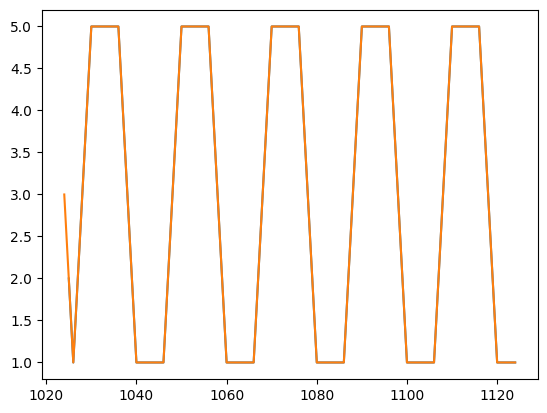

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.334592
1250 train done
1250 [6.0, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


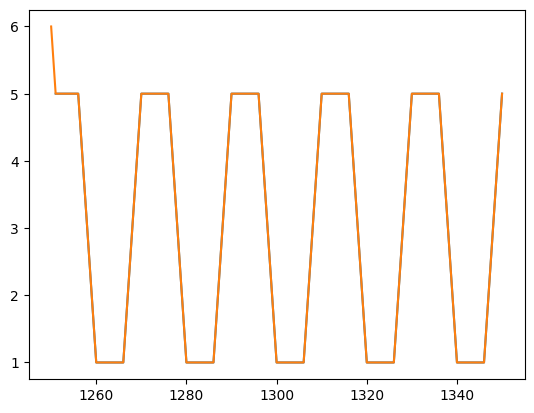

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.538619
1500 train done
1500 [3.0, 2, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.0


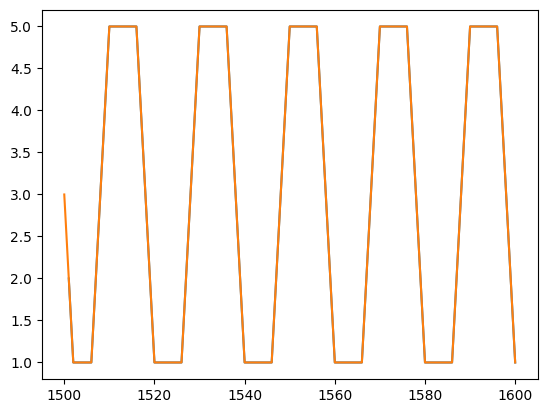

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.592137
2048 train done
2048 [6.0, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


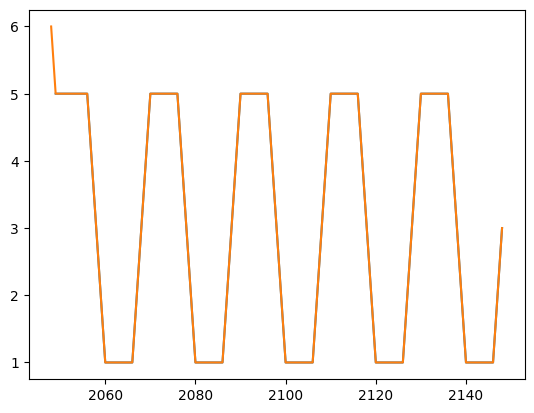

In [7]:
gamma = 0.5
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]

seeds = [115,215,315,415,515,615, 715,815,915,1015]
all_seed_results = {}
for seed in seeds:
    all_seed_results[seed] = {}

    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                        session_duration = 500000,
                                                        tdim=50, 
                                                        n_sessions=1,seed  = seed)
        state_posencode_oh = position_encoder(states[:,0], type="pe")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
        for T in Ts:
            X_train = new_state_oh[:T,:]
            Y_train = irewards[:T]
            print(X_train.shape)
        #convert to proper format for ydf
            df_train = pd.DataFrame(X_train)
            feature_labels = [f'feature_{i}' for i in range(X_train.shape[1])]
            df_train.columns = feature_labels
            df_train['target'] = Y_train


            rf = GradientBoostedTreesLearner(label = 'target', task = ydf.Task.REGRESSION, num_trees=1000)
        # rf = ObliqueRandomForestRegressor(n_estimators=1000)
            model = rf.train(df_train) #train now not fit
            print(T,'train done')
            current_state = states[T,0]
        # print(current_state)
            future_states = [current_state]
            for delta_t in range(100):
                df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            # print(f"Total paths: {len(df_all_paths)}")
            # states_seq = df_all_paths[state_cols].to_numpy() 

                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="pe")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                    features = np.hstack([cand_pe,time_emb])
                #convert to proper format for ydf
                    features_pd = pd.DataFrame(features, columns = feature_labels)
                    irewards_pred[:,i] = model.predict(features_pd)

            # # Compute instantaneous rewards
            # for i, row in df_all_paths.iterrows():
            #     for t in np.arange(t_prime+1):
            #         cand = row[f"t={T+delta_t+t}"]
            #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
            #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
            #         irewards_pred[i, t] = rf.predict(features)[0]

            # # Convert to DataFrame for inspection
                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
                rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
                discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
                discounted_returns = rewards_matrix * discounts  
                total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
                future_states.append(next_state)
                current_state = next_state
            # print(T+delta_t+1,current_state)
            print(T,future_states,len(future_states))
            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print(pregret)
            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()
        all_seed_results[seed][t_prime] = FUTURE_STATE.copy()


        


Processing seed: 115
Processing seed: 215
Processing seed: 315
Processing seed: 415
Processing seed: 515
Processing seed: 615
Pregrets shape: (6, 8)
Mean pregrets: [1.1505673  1.06691795 0.17301136 0.003105   0.         0.
 0.         0.        ]


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_18754/3014929090.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


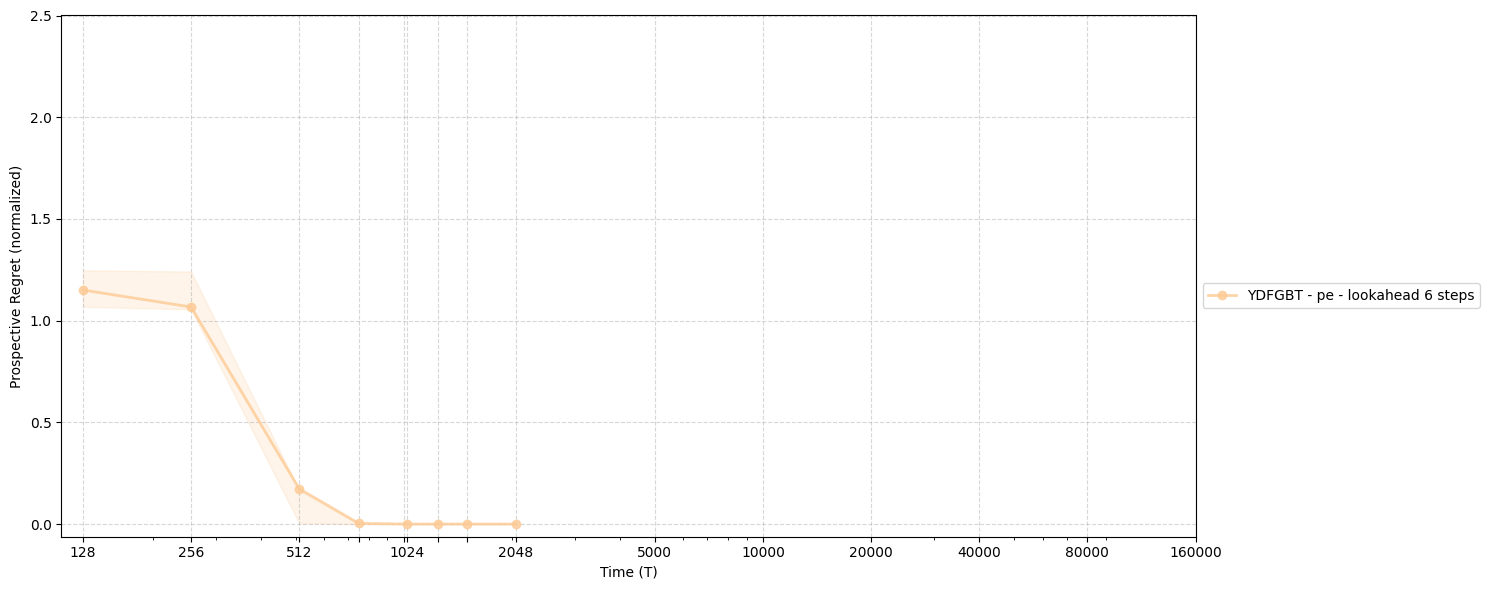

In [ ]:
from matplotlib import cm

def get_close_colors(cmap_name, start=0.5, delta=0.15, n=2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

pafm_pe_orf, pafm_oh_orf, pafm_pe, pafm_oh = get_close_colors("PuRd", start=0.1, delta=0.25, n=4)
skgbt_pe, skgbt_oh = get_close_colors("GnBu", start=0.1, delta=0.2, n=2) 
ydfgbt_pe, ydfgbt_oh = get_close_colors("YlOrBr", start=0.9, delta=0.2, n=2) 
ydfrf_pe, ydfrf_oh = get_close_colors("OrRd", start=0.1, delta=0.2, n=2) 

colors = {
    "YDFRF_pe": ydfrf_pe,
    "YDFRF_oh": ydfrf_oh
}

t_prime = 6
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
seeds = [115,215,315,415,515,615]

all_pregrets = []
all_prewards = []

for seed in seeds:
    print(f"Processing seed: {seed}")
    
    # Get the FUTURE_STATE data for this seed
    future_states_list = all_seed_results[seed][t_prime]
    
    prewards = []
    pregrets = []
    
    for k, T in enumerate(Ts):
        if k < len(future_states_list):
            # Get the future states for this T value
            states_trajectory = future_states_list[k]
            
            irewards = [reward_simulate(states_trajectory[i], T+i, rewards_in_period) 
                       for i in range(1, len(states_trajectory))]
            
            preward = compute_normalized_future_rewards(irewards, 100, 0.5)
            
            path, ireward_opt = path_opt(states_trajectory[0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:], 100, 0.5)
            
            pregret = (np.sum(preward_opt).item() - np.sum(preward).item()) / 100
            
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
        else:
            print(f"Warning: No data for T={T} in seed {seed}")
            prewards.append(np.nan)
            pregrets.append(np.nan)
    
    all_prewards.append(prewards)
    all_pregrets.append(pregrets)

# Convert to numpy arrays
PREWARDS_arr = np.array(all_prewards)
PREGRETS_arr = np.array(all_pregrets)

# Calculate mean and percentiles across seeds
PREGRETS_mean = np.nanmean(PREGRETS_arr, axis=0)
PREGRETS_25th = np.nanpercentile(PREGRETS_arr, 25, axis=0)
PREGRETS_75th = np.nanpercentile(PREGRETS_arr, 75, axis=0)

print(f"Pregrets shape: {PREGRETS_arr.shape}")
print(f"Mean pregrets: {PREGRETS_mean}")

plt.figure(figsize=(15, 6))

plt.plot(Ts, PREGRETS_mean, alpha=0.8, marker='o', color=colors["YDFRF_oh"], 
         label='YDFGBT - pe - lookahead 6 steps', linewidth=2, markersize=6)

plt.fill_between(Ts, PREGRETS_25th, PREGRETS_75th, 
                 alpha=0.2, color=colors["YDFRF_oh"])

Ts_PAFM = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
Ts_PVFM = [1000,5000,10000,20000,40000,80000,160000]

plt.xlabel("Time (T)")
plt.ylabel("Prospective Regret (normalized)")
plt.xscale('log')
xticks = Ts_PAFM + Ts_PVFM
xticklabels = [str(v) if v in [128,256,512,1024,2048,5000,10000,20000,40000,80000,160000] else ""
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels)
plt.yticks([0,0.5,1,1.5,2,2.5])

plt.legend(loc="upper left", bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()